In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

### Plots for main text figure

In [3]:
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.cluster_tuning import events
from GridMaze.maze import plotting as mp
from GridMaze.maze import representations as mr

In [4]:
reload(gc)
reload(events)
reload(mp)


def plot_single_unit_figs(cluster_unique_ID, save_label=False):
    """
    Plots the average and goal-stratified trial aligned tuning curves for a given cluster,
    with maze color key (returns separate figs that can be saved separately) and assembled
    into full figure.
    """
    Cluster = gc.get_cluster(cluster_unique_ID)
    f1, ax1 = plt.subplots(1, 1, figsize=(1.5, 0.5), clear=True)
    Cluster.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": False, "color": "black"}, ax=ax1)
    ax1.set_xticklabels([])
    ax1.set_ylabel("Hz")

    f2, ax2 = plt.subplots(1, 1, figsize=(6, 2), clear=True)
    Cluster.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": True}, ax=ax2)

    goals = Cluster.goals
    simple_maze = mr.get_simple_maze(Cluster.maze_name)
    f3, ax3 = plt.subplots(1, 1, figsize=(1.5, 1.5), clear=True)
    mp.plot_maze_legend(simple_maze, goals, ax=ax3)

    if save_label:
        f1.savefig(f"../results/goal_coding/example_clusters/{save_label}_inset.pdf")
        f2.savefig(f"../results/goal_coding/example_clusters/{save_label}_tuning.pdf")
        f3.savefig(f"../results/goal_coding/example_clusters/{save_label}_legend.pdf")
    else:
        return f1, f2, f3

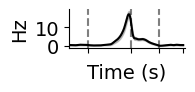

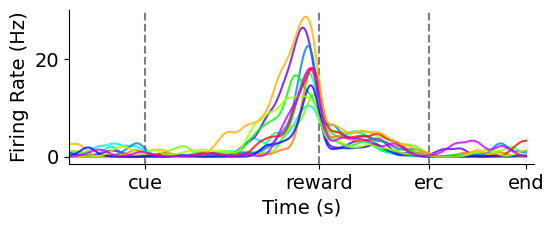

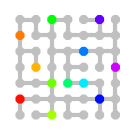

In [5]:
plot_single_unit_figs("m2.2022-07-04.maze_cluster65", save_label="cluster_1")

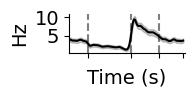

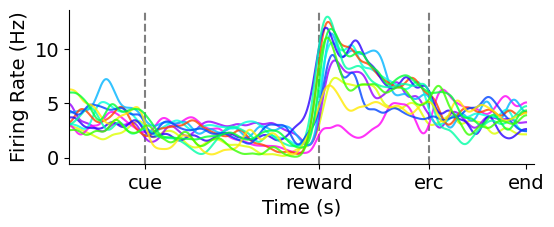

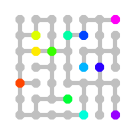

In [6]:
plot_single_unit_figs("m3.2022-07-17.maze_cluster45", save_label="cluster_2")

In [ ]:
# Load data
from GridMaze.analysis.event_aligned import allocentric_goal_decoding as agd
from GridMaze.analysis.event_aligned import delta_distance_to_goal as ddg
from GridMaze.analysis.event_aligned import reward_time_reps as rtr

RSM_comparisons_df = rtr.get_within_across_maze_RSM_comparison(
    maze_names=["maze_1", "maze_2"],  # rooms_maze
    alignment="event",
    window=(-0.25, 0.25),
)

rtr.plot_RDM_comparisons(RSM_comparisons_df, print_stats=True)

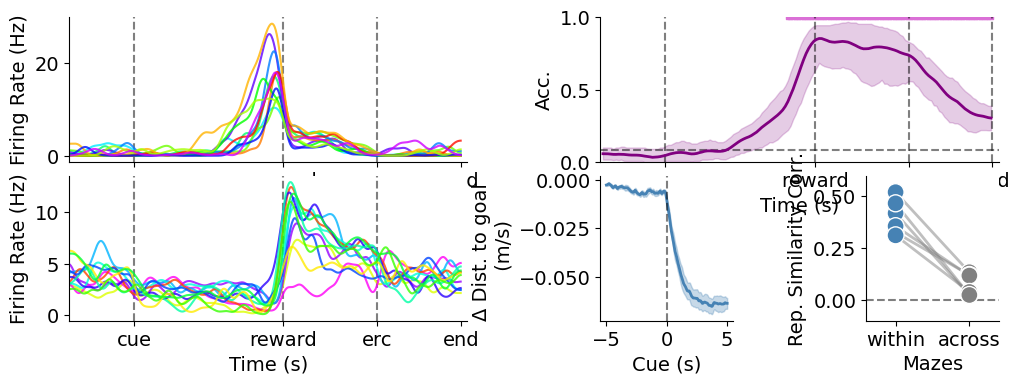

In [37]:
# plot summary figure
reload(agd)
reload(ddg)
reload(rtr)

fig = plt.figure(figsize=(12, 6), clear=True)
gsc = GridSpec(6, 4, figure=fig)
# asign axes
ax1 = fig.add_subplot(gsc[0:2, 0:2])  # example cluster 1
ax2 = fig.add_subplot(gsc[2:4, 0:2])  # example cluster 2
ax3 = fig.add_subplot(gsc[0:2, 2:4])  # goal decoding
ax4 = fig.add_subplot(gsc[2:4, 2])  # rate of change of distance to goal
ax5 = fig.add_subplot(gsc[2:4, 3])  # reward rep sim

# plot single units
cluster_1 = gc.get_cluster("m2.2022-07-04.maze_cluster65")
cluster_2 = gc.get_cluster("m3.2022-07-17.maze_cluster45")
cluster_1.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": True}, ax=ax1)
cluster_2.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": True}, ax=ax2)

# plot goal decoding
representiative_dataset = ("maze_1", "subset_2")
agd.plot_goal_decoding(
    datasets=[representiative_dataset],
    alignment="trial",
    decoder="logreg",
    bootstrap_method="input",
    ax=ax3,
)

# plot ddtg
ddg.plot_cross_subject_rate_of_change_of_distance_to_goal(ax=ax4, window_length=5, smooth_SD=6, color="steelblue")

# plot rewards sim
rtr.plot_RDM_comparisons(RSM_comparisons_df, ax=ax5, color="steelblue")

fig.subplots_adjust(wspace=1.0)

fig.savefig("../results/goal_coding/decoding_summary.pdf")

## Plots for extended data figure 

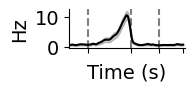

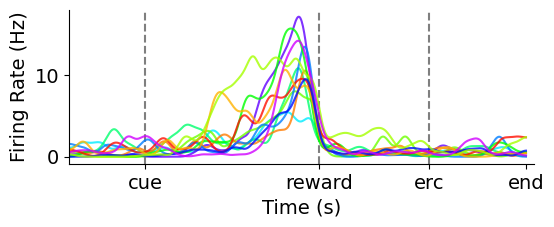

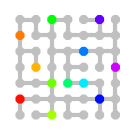

In [9]:
plot_single_unit_figs("m2.2022-07-04.maze_cluster114", save_label="cluster_3")

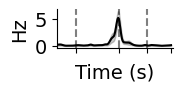

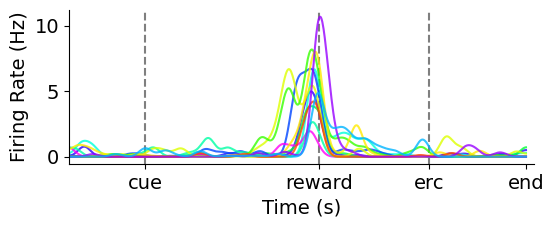

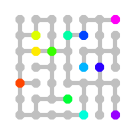

In [10]:
plot_single_unit_figs("m2.2022-07-17.maze_cluster50", save_label="cluster_4")

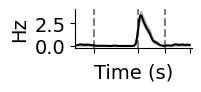

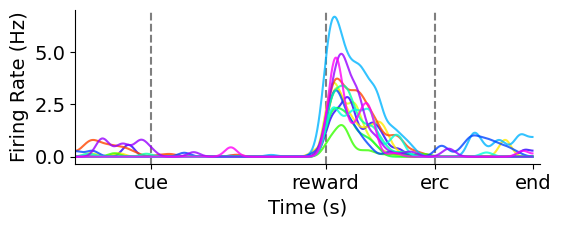

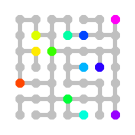

In [11]:
plot_single_unit_figs("m6.2022-07-05.maze_cluster134", save_label="cluster_5")

In [ ]:
# quick(er) summary plots of goal decoding analyses
from GridMaze.analysis.event_aligned import allocentric_goal_decoding as agd

reload(agd)

agd.plot_goal_decoding_heatmap_summary()

In [ ]:
# quick plotting function for decoding summary


def plot_decoding_summary(ax, goal_set, alignment, decoder):
    """ """
    bootstrap_method = "input" if goal_set != "all" else "output"
    # plot maze_1
    try:
        agd.plot_goal_decoding(
            datasets=[("maze_1", goal_set)],
            alignment=alignment,
            decoder=decoder,
            bootstrap_method=bootstrap_method,
            ax=ax,
            color="",
        )
    except:
        pass
    # plot maze_2
    try:
        agd.plot_goal_decoding(
            datasets=[("maze_2", goal_set)],
            alignment=alignment,
            decoder=decoder,
            bootstrap_method=bootstrap_method,
            ax=ax,
        )
    except:
        pass
    # plot rooms_maze
    try:
        agd.plot_goal_decoding(
            datasets=[("rooms_maze", goal_set)],
            alignment=alignment,
            decoder=decoder,
            bootstrap_method=bootstrap_method,
            ax=ax,
        )
    except:
        pass

Missing results for some subjects: {'m7'}


/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))


Missing results for some subjects: {'m7'}


/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))


Missing results for some subjects: {'m2', 'm6', 'm3', 'm4', 'm7', 'm8'}


/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))


Missing results for some subjects: {'m2', 'm6', 'm3', 'm4', 'm7', 'm8'}


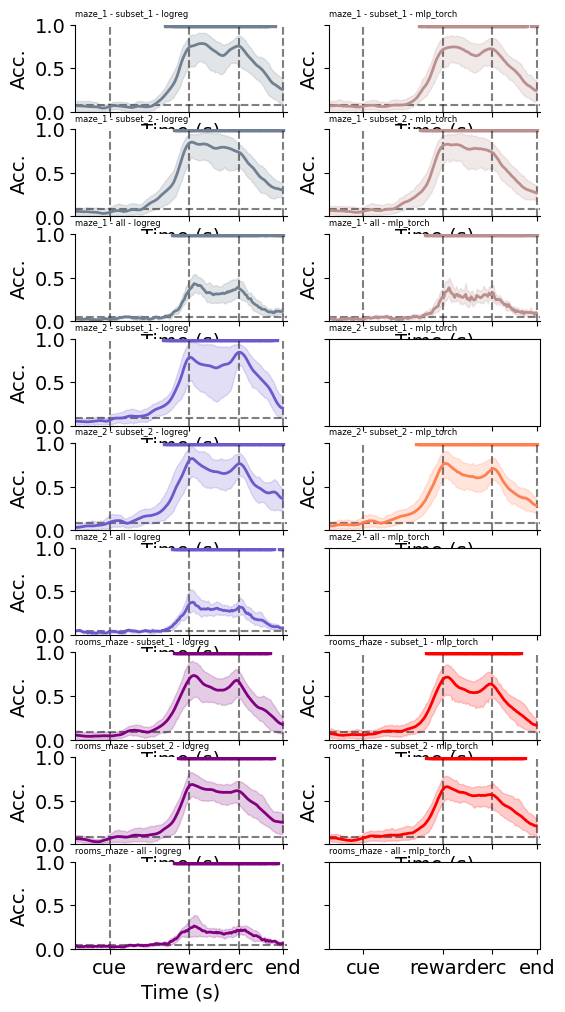

In [58]:
# plot detailed summary of decoding results
reload(agd)
mazes = ["maze_1", "maze_2", "rooms_maze"]
goal_sets = ["subset_1", "subset_2", "all"]
decoders = ["logreg", "mlp_torch"]

maze_colors = (
    ["slategray", "slateblue", "purple"],  # colors for logreg
    ["rosybrown", "coral", "red"],  # colors for mlp_torch
)

# 2) make a 9×2 grid
n_rows = len(mazes) * len(goal_sets)
n_cols = len(decoders)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, 12), sharex=True, sharey=True, clear=True)

# 3) loop over mazes & goal_sets to compute the row index,
#    then over decoders for the column index
for m_idx, maze in enumerate(mazes):
    for g_idx, goal_set in enumerate(goal_sets):
        row = m_idx * len(goal_sets) + g_idx
        for d_idx, decoder in enumerate(decoders):
            ax = axes[row, d_idx]
            color = maze_colors[d_idx][m_idx]
            bootstrap_method = "input" if goal_set != "all" else "output"
            try:
                agd.plot_goal_decoding(
                    datasets=[(maze, goal_set)],
                    alignment="trial",
                    decoder=decoder,
                    bootstrap_method=bootstrap_method,
                    ax=ax,
                    color=color,
                    sig_color=color,
                )
            except:
                pass
            ax.set_title(f"{maze} - {goal_set} - {decoder}", fontsize=6, loc="left")

Missing results for some subjects: {'m6', 'm4', 'm7', 'm8'}


/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))


Missing results for some subjects: {'m2', 'm6', 'm3', 'm4', 'm7', 'm8'}


/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))


Missing results for some subjects: {'m2', 'm6', 'm3', 'm4', 'm7', 'm8'}
Missing results for some subjects: {'m2', 'm6', 'm3', 'm4', 'm7', 'm8'}


/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(-pvals))


Missing results for some subjects: {'m2', 'm6', 'm3', 'm4', 'm7', 'm8'}
Missing results for some subjects: {'m2', 'm6', 'm3', 'm4', 'm7', 'm8'}


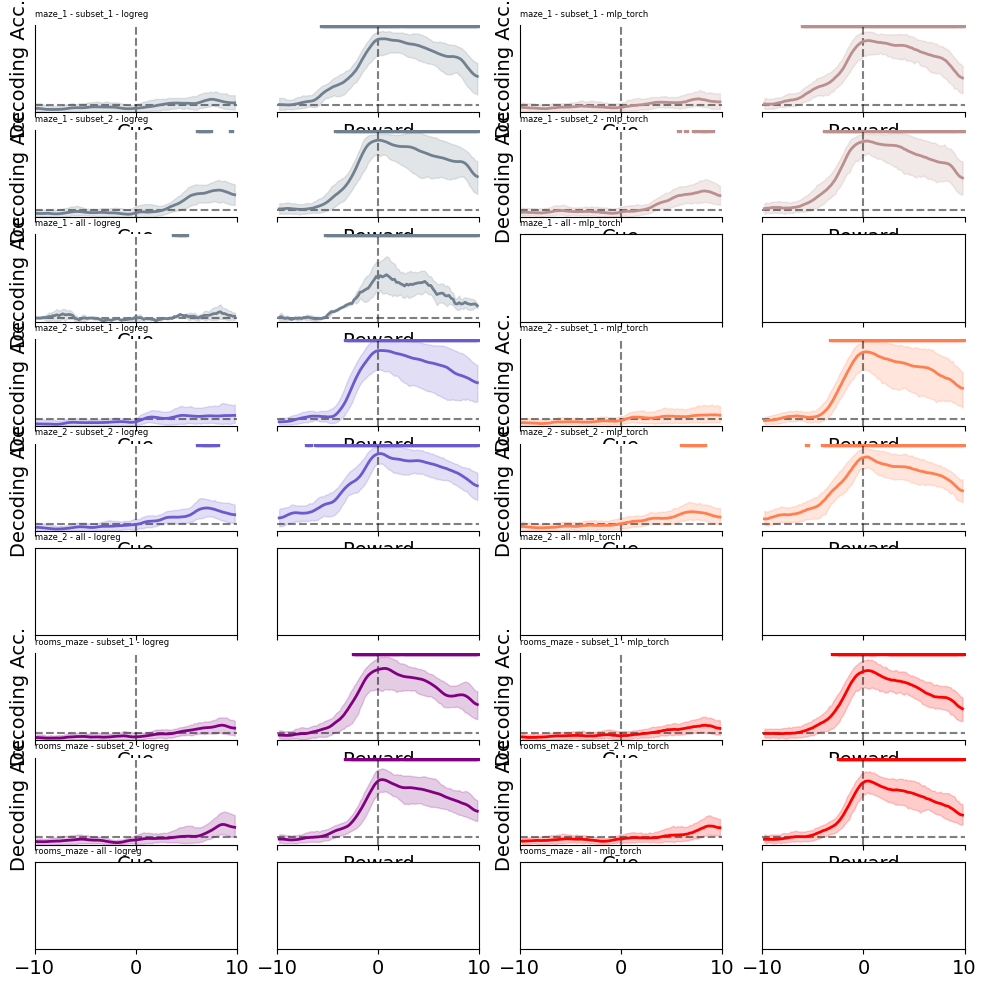

In [78]:
# 1) setup
reload(agd)
mazes = ["maze_1", "maze_2", "rooms_maze"]
goal_sets = ["subset_1", "subset_2", "all"]
decoders = ["logreg", "mlp_torch"]

maze_colors = (
    ["slategray", "slateblue", "purple"],  # logreg
    ["rosybrown", "coral", "red"],  # mlp_torch
)

# 2) make a 9×4 grid (2 decoders × 2 axes each)
n_rows = len(mazes) * len(goal_sets)
n_cols = 2 * len(decoders)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 12), sharex=True, sharey=True, clear=True)

# 3) loop rows × decoders, grabbing two cols per decoder
for m_idx, maze in enumerate(mazes):
    for g_idx, goal_set in enumerate(goal_sets):
        row = m_idx * len(goal_sets) + g_idx

        for d_idx, decoder in enumerate(decoders):
            # pick out the left/right axes
            col_base = d_idx * 2
            ax_left = axes[row, col_base]
            ax_right = axes[row, col_base + 1]

            color = maze_colors[d_idx][m_idx]
            bootstrap_method = "input" if goal_set != "all" else "output"

            try:
                agd.plot_goal_decoding(
                    datasets=[(maze, goal_set)],
                    alignment="event",
                    decoder=decoder,
                    bootstrap_method=bootstrap_method,
                    ax=(ax_left, ax_right),  # <-- two‐axis signature
                    color=color,
                    sig_color=color,
                )
            except Exception:
                pass

            # only title the left‐hand plot
            ax_left.set_title(f"{maze} - {goal_set} - {decoder}", fontsize=6, loc="left")

In [64]:
# plot locomotion controlled version of reward rep sim analysis
reload(rtr)
RSM_comparisons_df2 = rtr.get_within_across_maze_RSM_comparison(
    maze_names=["maze_1", "maze_2"],  # rooms_maze
    alignment="trial",
    window=(0, 1),
)

T-statistic: 3.9835
P-value: 0.0105
Degrees of freedom: 5


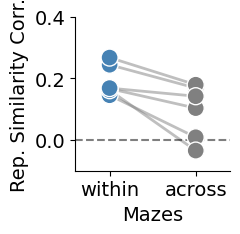

In [71]:
reload(rtr)
rtr.plot_RDM_comparisons(RSM_comparisons_df2, color="steelblue", print_stats=True, ymax=0.4)